#### Examples_Sub-step.ipynb

In this notebook, we show how to reduce the total runtime while maintaining numerical stability by introducing a sub‑stepping scheme for particles inside a chosen radius $r_p$


Particles are divided according to their distance from the central object: those with radius $r<r_p$ are evolved with a shorter timestep, while particles outside this region use a larger outer timestep. The ratio between the inner and outer timesteps is controlled by the parameter $N_p$, which specifies how many inner sub‑steps are taken per outer step. 

We set up central black hole, surrounded by a DM spike and evolve it forward with different time step setting.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 18})

from NbodyIMRI import tools, particles, simulator, reader
from NbodyIMRI import units as u
from NbodyIMRI import distributionfunctions as DF
import NbodyIMRI

import copy

#### Setting up the system parameters


In [3]:
M_1 = 1e3*u.Msun

r_isco = 6*u.G_N*M_1/u.c**2

rho_6 = 1e16*u.Msun/u.pc**3 #Normalisation of the spike
gamma_sp = 7/3

N_DM = 10000

In [4]:
5*10**-8*u.pc/r_isco

174.38170061684625

In [5]:
r_max = 1e-2*u.pc #max radius
r_t= 2000*r_isco #smooth truncation radius

#### Setting up the simulator - no sub-stepping

In [6]:
#Let's set the time step to a fraction of the orbital time at a distance of 1e-8 pc
T_orb = tools.calc_Torb(a_i = 5e-8*u.pc, M_tot = M_1)
N_step_per_orb = 1000
dt  = T_orb/N_step_per_orb 

print(dt)
N_orb = 10
t_end = T_orb*N_orb

1.0452140590555636


Let's generate the particles and run the simulation

> Particle set:
>     M_1 [M_sun] = 1000.0
 
>     N_DM = 10000
>     M_DM [M_sun] = 1.0488337378336059e-05


(<Figure size 1152x360 with 3 Axes>,
 array([<AxesSubplot:xlabel='$x$ [pc]', ylabel='$y$ [pc]'>,
        <AxesSubplot:xlabel='$x$ [pc]', ylabel='$z$ [pc]'>,
        <AxesSubplot:xlabel='$\\log_{10}(r/\\mathrm{pc})$', ylabel='$P(\\log_{10}(r/\\mathrm{pc}))$'>],
       dtype=object))

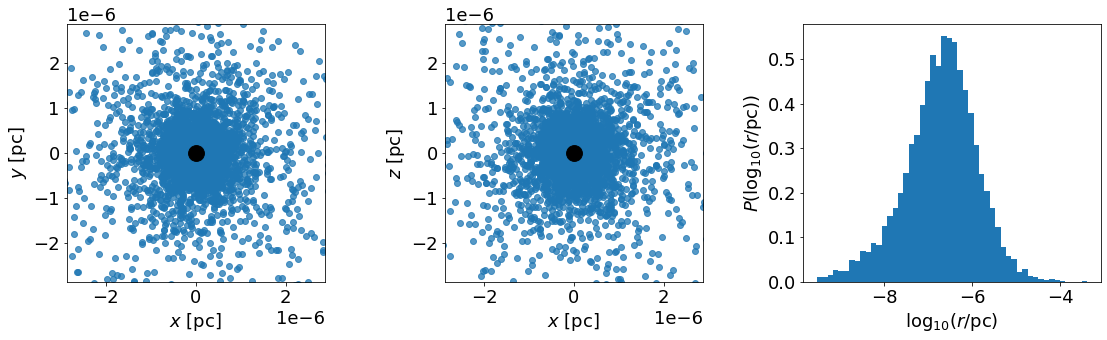

In [7]:
p_BH = particles.single_BH(M_1, N_DM = N_DM, rho_6 = rho_6, gamma_sp = gamma_sp, r_max = r_max, r_t =r_t)

p_BH.summary()
p_BH.plot()

In [8]:
#Set the softening length
eps1 = 10*r_isco
#Initialise the simulator
sim = simulator.simulator(p_BH, r_soft_sq1 = eps1**2)
#run the simulation
sim.run_simulation(dt, t_end, show_progress=True)

> Simulating...


100%|██████████| 10000/10000 [00:21<00:00, 470.67it/s]

> Simulation completed.


Now let's multiply the time step by ten and run another simulation:

In [9]:
dt_long=dt*10

sim_fast = simulator.simulator(p_BH, r_soft_sq1 = eps1**2)
sim_fast.run_simulation(dt_long, t_end, show_progress=True)

> Simulating...


100%|██████████| 1000/1000 [00:01<00:00, 570.19it/s]

> Simulation completed.


Much faster, but is it stable? Let's plot the density profiles to find out

In [10]:
def get_density_profile(p_in, bins = None):
    p = copy.deepcopy(p_in)
    rDM = tools.norm(p.xDM - p.xBH1)
    vDM = tools.norm(p.vDM - p.vBH1)
    
    r_isco = 6*u.G_N*p.M_1/u.c**2
    
    if bins is None:
        bins = np.geomspace(1, 1e5, 101)*r_isco
    
    #Bin edges and widths
    rc = np.sqrt(bins[:-1]*bins[1:])
    dr = np.diff(bins)
    
    #Reconstruct dn/dr
    nDM, _ = np.histogram(rDM, bins=bins)
    
    #Reconstruct rho = m_DM*dn/dV
    M_pseudo = p.M_DM[0]
    shell_volumes = (4*np.pi/3)*(bins[1:]**3 - bins[:-1]**3)
    rhoDM = M_pseudo*nDM/shell_volumes
    
    return rc, rhoDM

In [11]:
rc, rho_i = get_density_profile(p_BH)
rc, rho_f = get_density_profile(sim.p)
rc, rho_f_fast = get_density_profile(sim_fast.p)

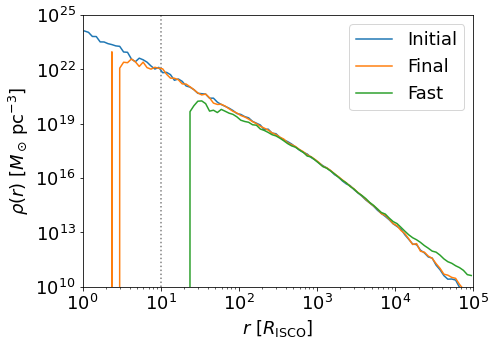

In [12]:
plt.figure(figsize=(7,5))

plt.axvline(eps1/r_isco, linestyle=':', color='gray')
#plt.axhline(1, linestyle='--', color='k')

plt.loglog(rc/r_isco, rho_i/(u.Msun/u.pc**3), label='Initial')
plt.semilogx(rc/r_isco, rho_f/(u.Msun/u.pc**3), label='Final')
plt.semilogx(rc/r_isco, rho_f_fast/(u.Msun/u.pc**3), label='Fast')


plt.xlim(1, 1e5)
plt.ylim(1e10, 1e25)

plt.legend()

plt.xlabel(r"$r$ [$R_\mathrm{ISCO}$]")
plt.ylabel(r"$\rho(r)$ [$M_\odot \,\mathrm{pc}^{-3}$]")

plt.show()

The simulator on the shorter time step cannot resolve the trajectories of the inner particles, which are escaping to the outskirts. 

#### Sub-stepping

With the sub-step option, we can place the inner particles on a shorter time step than the rest, ensuring we can resolve their motion.

We introduce two new parameters:

- $r_p$ : threshold radius. Particles with distance

         $ r<r_p$
    are assigned to the inner group and evolve with a shorter timestep.
    
- $N_p$: multiplicative factor controlling the timestep ratio

    $N_p= \dfrac{M_\mathrm{inner}}{M_\mathrm{outer}}$
    
    For example, $N_p = 10$ means the inner particles take 10 sub‑steps for every outer step.

In [13]:
r_p=30*r_isco
N_p=10

We initialize agian the particles, now passing the argument $r_p$ 

In [15]:
p_BH_substep = particles.single_BH(M_1, N_DM = N_DM, rho_6 = rho_6, gamma_sp = gamma_sp, r_max = r_max, r_t =r_t, r_p=r_p)

p_BH_substep.summary()


> Particle set:
>     M_1 [M_sun] = 1000.0
 
>     N_DM = 10000
>     M_DM [M_sun] = 1.0488337378336059e-05


Let's count how many particles are in the inner partition

In [16]:
print("inner particles:", len(p_BH_substep.xDM_in))
print("outer particles:", len(p_BH_substep.xDM_out))

inner particles: 754
outer particles: 9246


Now let's run the simulation again using the long time step

In [17]:
sim_substep = simulator.simulator(p_BH_substep, r_soft_sq1 = eps1**2)
sim_substep.run_simulation(dt_long, t_end, show_progress=True)

> Simulating...


100%|██████████| 1000/1000 [00:07<00:00, 128.02it/s]

> Simulation completed.


And let's plot the profiles

In [18]:
rc, rho_f_substep = get_density_profile(sim_substep.p)

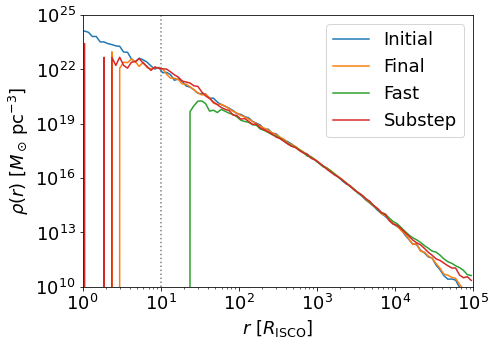

In [19]:
plt.figure(figsize=(7,5))


plt.axvline(10*r_isco/r_isco, linestyle=':', color='gray')
#plt.axhline(1, linestyle='--', color='k')

plt.loglog(rc/r_isco, rho_i/(u.Msun/u.pc**3), label='Initial')
plt.semilogx(rc/r_isco, rho_f/(u.Msun/u.pc**3), label='Final')
plt.semilogx(rc/r_isco, rho_f_fast/(u.Msun/u.pc**3), label='Fast')
plt.semilogx(rc/r_isco, rho_f_substep/(u.Msun/u.pc**3), label='Substep')


plt.xlim(1, 1e5)
plt.ylim(1e10, 1e25)

plt.legend()

plt.xlabel(r"$r$ [$R_\mathrm{ISCO}$]")
plt.ylabel(r"$\rho(r)$ [$M_\odot \,\mathrm{pc}^{-3}$]")

plt.show()